## Análisis Univariable de los datos

### By: Maricel Martinez

### Date: 2026-08-26

### Description:

Análisis exploratorio de los datos (EDA) para caracterizar los datos disponibles para el proyecto.

### Requerimiento

Realizar un buen análisis de datos exploratorio (EDA) para caracterizar los datos disponibles para el proyecto. Crear una nueva rama de git (Usar [Gitflow](https://joserzapata.github.io/courses/ciencia-datos-en-produccion/control-versiones/branching-model/)).

Tomar como ejemplo los pasos de: [Análisis de datos](https://joserzapata.github.io/post/ciencia-datos-proyecto-python/3-analysis/)

Si su proyecto tiene muchos datos puede dividir el análisis en 3 notebooks diferentes:

- Análisis univariable
- Análisis bivariable
- Análisis multivariable

En este proceso, se incluye:

- Compresión detallada de las características y el esquema de datos.
- Identificación de la preparación de datos y la ingeniería de atributos que se necesitan si se fuera a implementar un modelo de machine learning
- Estudiar cada atributo y sus características (Análisis Univariable):
  - Nombre
  - Tipo de dato (categórico ordinal, nominal, numérico int / float, acotado / no acotado, texto, estructurado, fechas, etc.)
  - porcentaje (%) de valores nulos.
  - valores exactamente duplicados (filas y columnas)
  - Ruido y tipo de ruido (estocástico, valores atípicos, errores de redondeo, etc.)
  - ¿Son posiblemente útiles para el proyecto?
  - Descripción estadística (dependiendo del tipo de dato): por ejemplo para los numéricos
    - Tendencia Central (media, mediana, moda, max, min, etc)
    - Medidas de dispersión (Rango, IQR, cuartiles, varianza, desviación estándar, skewness y kurtosis)
    - Tipo de distribución (gaussiana, uniforme, logarítmica, etc.)
  - Analice los datos para crear las reglas de validación de los datos que serán usadas en otra etapa del proyecto.
- Para los proyectos de aprendizaje supervisado, identifique los atributos objetivo (target).
- Visualización de los datos.
- Estudiar las relaciones entre atributos (Análisis Bivariable)
- Estudiar las relaciones entre varios atributos (Análisis Multivariable)
- Estudiar cómo resolver el problema manualmente. (modelo simple Viable o heurísticas)
- Identificar las transformaciones que tal vez se puedan aplicar.
- Identificar datos adicionales que pueden ser útiles.

Puede utilizar las librerías o herramientas que considere para resolver la tarea y contestar las preguntas.

Utilice sistemas automáticos como [Data science Agent](https://developers.googleblog.com/en/data-science-agent-in-colab-with-gemini/) pueden ver un tutorial en este [Link](https://www.youtube.com/watch?v=1WAjTyYEIos)

# Entregables

Notebook con los resultados del análisis exploratorio de los datos, conclusiones e información de los datos.

¿Sugerir si se puede realizar un modelo Heurístico que sea viable?

Se debe realizar un Pull request para ingresar el notebook a la rama `main` para esto debe tener mínimo 1 revisiones de otras personas del Curso y que pase los check del CI/CD.

## 📚 Import  libraries

In [1]:
# base libraries for data science
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Configuración

In [2]:
# configuration to show only 2 decimal places
pd.set_option("display.float_format", "{:.2f}".format)

# configuration for plots
sns.set_theme(style="whitegrid")

# Versiones

In [3]:
print("Python version:", sys.version)
print("Pandas version:", pd.__version__)
print("Seaborn version:", sns.__version__)

Python version: 3.12.13 (main, Aug  5 2026, 15:44:22) [Clang 22.1.3 ]
Pandas version: 3.0.5
Seaborn version: 0.13.2


## 💾 Load data

In [5]:
DATA_DIR = Path.cwd().resolve().parents[1] / "data"

boston_df = pd.read_parquet(
    DATA_DIR / "02_intermediate/boston_type_fixed.parquet",
    engine="pyarrow",
)

# Comprensión general de los datos

## Información general

In [6]:
boston_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 343 entries, 0 to 342
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     339 non-null    float64
 1   zn       343 non-null    float64
 2   indus    339 non-null    float64
 3   chas     343 non-null    float64
 4   nox      341 non-null    float64
 5   rm       340 non-null    float64
 6   age      342 non-null    float64
 7   dis      340 non-null    float64
 8   rad      342 non-null    float64
 9   tax      340 non-null    float64
 10  ptratio  342 non-null    float64
 11  black    341 non-null    float64
 12  lstat    343 non-null    float64
 13  medv     331 non-null    float64
dtypes: float64(14)
memory usage: 37.6 KB


### Interpretación de la estructura general

El dataset contiene 343 observaciones y 14 variables. Todas las columnas están almacenadas como `float64`; sin embargo, este tipo de dato no implica que todas las variables sean continuas. En particular, `chas` es una variable binaria con valores 0 y 1, mientras que `rad` es una variable discreta con un número limitado de categorías. Por tanto, la interpretación de las variables debe considerar su naturaleza además del tipo de dato almacenado.

## Dimensiones

In [7]:
print("Número de filas:", boston_df.shape[0])
print("Número de columnas:", boston_df.shape[1])
print("Dimensiones:", boston_df.shape)

Número de filas: 343
Número de columnas: 14
Dimensiones: (343, 14)


### Interpretación de las dimensiones

El conjunto de datos está compuesto por 343 observaciones y 14 variables. De estas, 13 corresponden a variables predictoras y `medv` corresponde a la variable objetivo. El tamaño del conjunto de datos deberá considerarse al tomar decisiones posteriores sobre el tratamiento de valores faltantes, duplicados y posibles valores extremos.

## Primeras observaciones

In [8]:
boston_df.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat,medv
0,0.01,18.00,2.31,0.00,0.54,6.58,65.20,4.09,1.00,296.00,15.30,396.90,4.98,24.00
1,0.03,0.00,7.07,0.00,0.47,6.42,78.90,4.97,2.00,242.00,17.80,396.90,9.14,21.60
2,0.03,0.00,2.18,0.00,0.46,7.00,45.80,6.06,3.00,222.00,18.70,394.63,2.94,33.40
3,0.07,0.00,2.18,0.00,0.46,7.15,54.20,6.06,3.00,222.00,18.70,396.90,5.33,NaN
4,0.09,12.50,7.87,0.00,0.52,6.01,66.60,5.56,5.00,311.00,15.20,395.60,12.43,22.90


In [9]:
boston_df.sample(5, random_state=42)

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat,medv
237,4.26,0.00,18.10,0.00,0.77,6.11,81.30,2.51,24.00,666.00,20.20,390.74,12.67,22.60
116,1.21,0.00,19.58,0.00,0.60,5.88,94.60,2.43,5.00,403.00,14.70,292.29,14.43,17.40
113,2.01,0.00,19.58,0.00,0.60,7.93,96.20,2.05,5.00,403.00,14.70,369.30,3.70,50.00
42,0.02,17.50,1.38,0.00,0.42,7.10,59.50,9.22,3.00,216.00,18.60,393.24,8.05,33.00
126,0.07,0.00,2.46,0.00,0.49,7.76,83.30,2.74,3.00,193.00,17.80,395.56,7.56,39.80


### Interpretación de las observaciones

La inspección inicial permite observar la estructura de las variables y sus diferentes escalas de medición. También se identifican valores faltantes representados como `NaN`, lo que confirma la necesidad de evaluar su distribución y definir posteriormente un tratamiento adecuado.

# Identificación de variables

## Tipos de datos

In [10]:
boston_df.dtypes

crim       float64
zn         float64
indus      float64
chas       float64
nox        float64
rm         float64
age        float64
dis        float64
rad        float64
tax        float64
ptratio    float64
black      float64
lstat      float64
medv       float64
dtype: object

### Interpretación de los tipos de dato

Todas las variables se encuentran almacenadas como `float64`. No obstante, su naturaleza estadística es diferente: `chas` es una variable binaria, `rad` es una variable discreta con un conjunto limitado de valores y las demás variables se consideran continuas para efectos del análisis exploratorio. Esta distinción será importante al seleccionar las técnicas de visualización y detección de valores atípicos.

## Resumen de variables

In [11]:
variable_summary = pd.DataFrame({
    "variable": boston_df.columns,
    "dtype": boston_df.dtypes.values,
    "n_unique": boston_df.nunique().values,
    "n_missing": boston_df.isnull().sum().values,
})

variable_summary["missing_%"] = (
    variable_summary["n_missing"] / len(boston_df) * 100
).round(2)

variable_summary

,variable,dtype,n_unique,n_missing,missing_%
0,crim,float64,328,4,1.17
1,zn,float64,25,0,0.00
2,indus,float64,68,4,1.17
3,chas,float64,2,0,0.00
4,nox,float64,77,2,0.58
5,rm,float64,306,3,0.87
6,age,float64,260,1,0.29
7,dis,float64,292,3,0.87
8,rad,float64,9,1,0.29
9,tax,float64,59,3,0.87


### Interpretación del resumen de variables

Se observa que los valores faltantes están distribuidos en la mayoría de las variables, aunque en proporciones relativamente bajas. `medv` presenta la mayor cantidad de valores nulos, con 12 observaciones (3.50 %). Por otra parte, `chas` y `lstat` no presentan valores faltantes. La cardinalidad también permite distinguir variables discretas, como `chas` y `rad`, de aquellas con una mayor cantidad de valores distintos.

# Valores nulos

## Cantidad de valores nulos

In [12]:
missing_values = boston_df.isnull().sum()

missing_values

crim        4
zn          0
indus       4
chas        0
nox         2
rm          3
age         1
dis         3
rad         1
tax         3
ptratio     1
black       2
lstat       0
medv       12
dtype: int64

## Porcentaje de valores nulos

In [13]:
missing_percentage = (
    boston_df.isnull().mean() * 100
).round(2)

missing_percentage.sort_values(ascending=False)

medv      3.50
crim      1.17
indus     1.17
rm        0.87
dis       0.87
tax       0.87
nox       0.58
black     0.58
rad       0.29
age       0.29
ptratio   0.29
zn        0.00
chas      0.00
lstat     0.00
dtype: float64

## Tabla de valores faltantes

In [14]:
missing_summary = pd.DataFrame({
    "missing_values": boston_df.isnull().sum(),
    "missing_percentage": (boston_df.isnull().mean() * 100).round(2),
})

missing_summary.sort_values(
    "missing_percentage",
    ascending=False
)

,missing_values,missing_percentage
medv,12,3.50
crim,4,1.17
indus,4,1.17
rm,3,0.87
dis,3,0.87
tax,3,0.87
nox,2,0.58
black,2,0.58
rad,1,0.29
age,1,0.29


### Interpretación de los valores nulos

Los valores faltantes se presentan en 12 de las 14 variables y en proporciones relativamente bajas. `medv` concentra la mayor cantidad, con 12 valores nulos (3.50 %), mientras que las demás variables presentan porcentajes inferiores. Aunque no se observa un problema masivo de datos faltantes, será necesario definir su tratamiento en la etapa de preparación de datos. En particular, los registros con valores faltantes en la variable objetivo deberán evaluarse cuidadosamente antes del entrenamiento de los modelos.

# Duplicados

## Filas duplicadas

In [15]:
duplicated_rows = boston_df.duplicated().sum()

print("Filas duplicadas:", duplicated_rows)

Filas duplicadas: 10


### Interpretación de las filas duplicadas

Se identificaron 10 filas completamente duplicadas, es decir, registros en los que coinciden los valores de todas las variables. Estos registros representan aproximadamente el 2.9 % del conjunto de datos y deberán revisarse en la etapa de preparación de datos para evitar que observaciones repetidas tengan una influencia adicional sobre los análisis y modelos posteriores.

## Duplicados por columna

In [16]:
duplicated_by_column = {}

for column in boston_df.columns:
    duplicated_by_column[column] = boston_df[column].duplicated().sum()

duplicated_by_column = pd.Series(duplicated_by_column)

duplicated_by_column

crim        14
zn         318
indus      274
chas       341
nox        265
rm          36
age         82
dis         50
rad        333
tax        283
ptratio    300
black      105
lstat       33
medv       154
dtype: int64

### Interpretación de los duplicados por columna

La presencia de valores repetidos dentro de una variable no constituye por sí misma un problema de calidad de datos. Es esperable que variables con baja cardinalidad, como `chas` y `rad`, presenten una elevada cantidad de valores repetidos. Por esta razón, este resultado se utiliza principalmente para caracterizar la distribución y cardinalidad de las variables, mientras que la identificación de filas completamente duplicadas constituye el indicador relevante para evaluar registros redundantes.

# Estadística descriptiva

## Estadística general

In [17]:
boston_df.describe().T

,count,mean,std,min,25%,50%,75%,max
crim,339.00,3.31,7.30,0.01,0.08,0.26,3.44,73.53
zn,343.00,10.81,22.93,0.00,0.00,0.00,12.50,100.00
indus,339.00,11.03,6.89,0.74,5.13,8.56,18.10,27.74
chas,343.00,0.06,0.23,0.00,0.00,0.00,0.00,1.00
nox,341.00,0.56,0.11,0.39,0.45,0.54,0.62,0.87
rm,340.00,6.27,0.70,3.56,5.89,6.18,6.59,8.72
age,342.00,67.84,28.55,6.00,44.03,76.70,93.88,100.00
dis,340.00,3.75,1.97,1.13,2.14,3.18,5.21,10.71
rad,342.00,9.46,8.69,1.00,4.00,5.00,24.00,24.00
tax,340.00,404.97,170.74,188.00,277.00,329.00,666.00,711.00


### Interpretación de la estadística descriptiva

Las variables presentan rangos, medias y medianas considerablemente diferentes. Algunas muestran una diferencia amplia entre sus valores centrales y extremos, lo que sugiere distribuciones asimétricas y la posible presencia de observaciones extremas. Estas características se analizarán con mayor detalle mediante las medidas de asimetría, curtosis, histogramas y boxplots.

## Estadísticos adicionales

In [18]:
numeric_summary = pd.DataFrame({
    "mean": boston_df.mean(),
    "median": boston_df.median(),
    "std": boston_df.std(),
    "variance": boston_df.var(),
    "min": boston_df.min(),
    "max": boston_df.max(),
    "range": boston_df.max() - boston_df.min(),
    "q1": boston_df.quantile(0.25),
    "q3": boston_df.quantile(0.75),
    "IQR": boston_df.quantile(0.75) - boston_df.quantile(0.25),
    "skewness": boston_df.skew(),
    "kurtosis": boston_df.kurtosis(),
})

numeric_summary.round(2)

,mean,median,std,variance,min,max,range,q1,q3,IQR,skewness,kurtosis
crim,3.31,0.26,7.30,53.23,0.01,73.53,73.53,0.08,3.44,3.36,4.64,31.47
zn,10.81,0.00,22.93,525.95,0.00,100.00,100.00,0.00,12.50,12.50,2.34,4.62
indus,11.03,8.56,6.89,47.49,0.74,27.74,27.00,5.13,18.10,12.97,0.36,-1.17
chas,0.06,0.00,0.23,0.06,0.00,1.00,1.00,0.00,0.00,0.00,3.79,12.41
nox,0.56,0.54,0.11,0.01,0.38,0.87,0.49,0.45,0.62,0.17,0.73,-0.05
rm,6.27,6.18,0.70,0.48,3.56,8.72,5.16,5.89,6.59,0.71,0.31,2.16
age,67.84,76.70,28.55,815.01,6.00,100.00,94.00,44.03,93.88,49.85,-0.60,-0.96
dis,3.75,3.18,1.97,3.89,1.13,10.71,9.58,2.14,5.21,3.07,0.88,0.04
rad,9.46,5.00,8.69,75.44,1.00,24.00,23.00,4.00,24.00,20.00,1.02,-0.82
tax,404.97,329.00,170.74,29153.29,188.00,711.00,523.00,277.00,666.00,389.00,0.68,-1.14


### Interpretación de la asimetría y curtosis

Las medidas de asimetría muestran comportamientos diferenciados entre las variables. `crim` (4.64) y `zn` (2.34) presentan una marcada asimetría positiva, mientras que `black` (-3.00) presenta una marcada asimetría negativa. En `medv`, la asimetría es positiva y moderada (1.13), indicando una mayor concentración de observaciones hacia valores inferiores y una cola hacia valores superiores.

Los valores elevados de curtosis observados en algunas variables, particularmente `crim` (31.47), `chas` (12.41) y `black` (8.11), indican distribuciones con colas más pronunciadas y/o mayor concentración alrededor de determinados valores. Estos resultados deben interpretarse considerando la naturaleza de cada variable, especialmente en el caso de `chas`, que es binaria.

# Moda

## Moda de cada variable

In [19]:
mode_summary = boston_df.mode().iloc[0]

mode_summary

crim        0.02
zn          0.00
indus      18.10
chas        0.00
nox         0.54
rm          5.71
age       100.00
dis         5.72
rad        24.00
tax       666.00
ptratio    20.20
black     396.90
lstat      18.13
medv       50.00
Name: 0, dtype: float64

### Interpretación de la moda

La moda resulta especialmente útil para caracterizar variables discretas o con pocos valores posibles. En `chas`, la moda es 0.00, lo que indica que esta categoría es la más frecuente. En `rad` y `tax` también se observa una concentración importante en determinados valores, por lo que su distribución debe interpretarse junto con los histogramas y las frecuencias observadas.

# Análisis individual de cada variable

## Valores únicos

In [20]:
unique_summary = pd.DataFrame({
    "variable": boston_df.columns,
    "unique_values": boston_df.nunique(),
    "unique_percentage": (
        boston_df.nunique() / len(boston_df) * 100
    ).round(2),
})

unique_summary

,variable,unique_values,unique_percentage
crim,crim,328,95.63
zn,zn,25,7.29
indus,indus,68,19.83
chas,chas,2,0.58
nox,nox,77,22.45
rm,rm,306,89.21
age,age,260,75.80
dis,dis,292,85.13
rad,rad,9,2.62
tax,tax,59,17.20


### Interpretación de los valores únicos

La cardinalidad confirma diferencias importantes entre las variables. `chas` presenta únicamente 2 valores distintos, correspondientes a una variable binaria, mientras que `rad` presenta 9 valores distintos y debe considerarse una variable discreta. Las demás variables presentan una mayor cantidad de valores únicos y se comportan como variables continuas dentro del análisis exploratorio.

# Distribuciones

## Histogramas

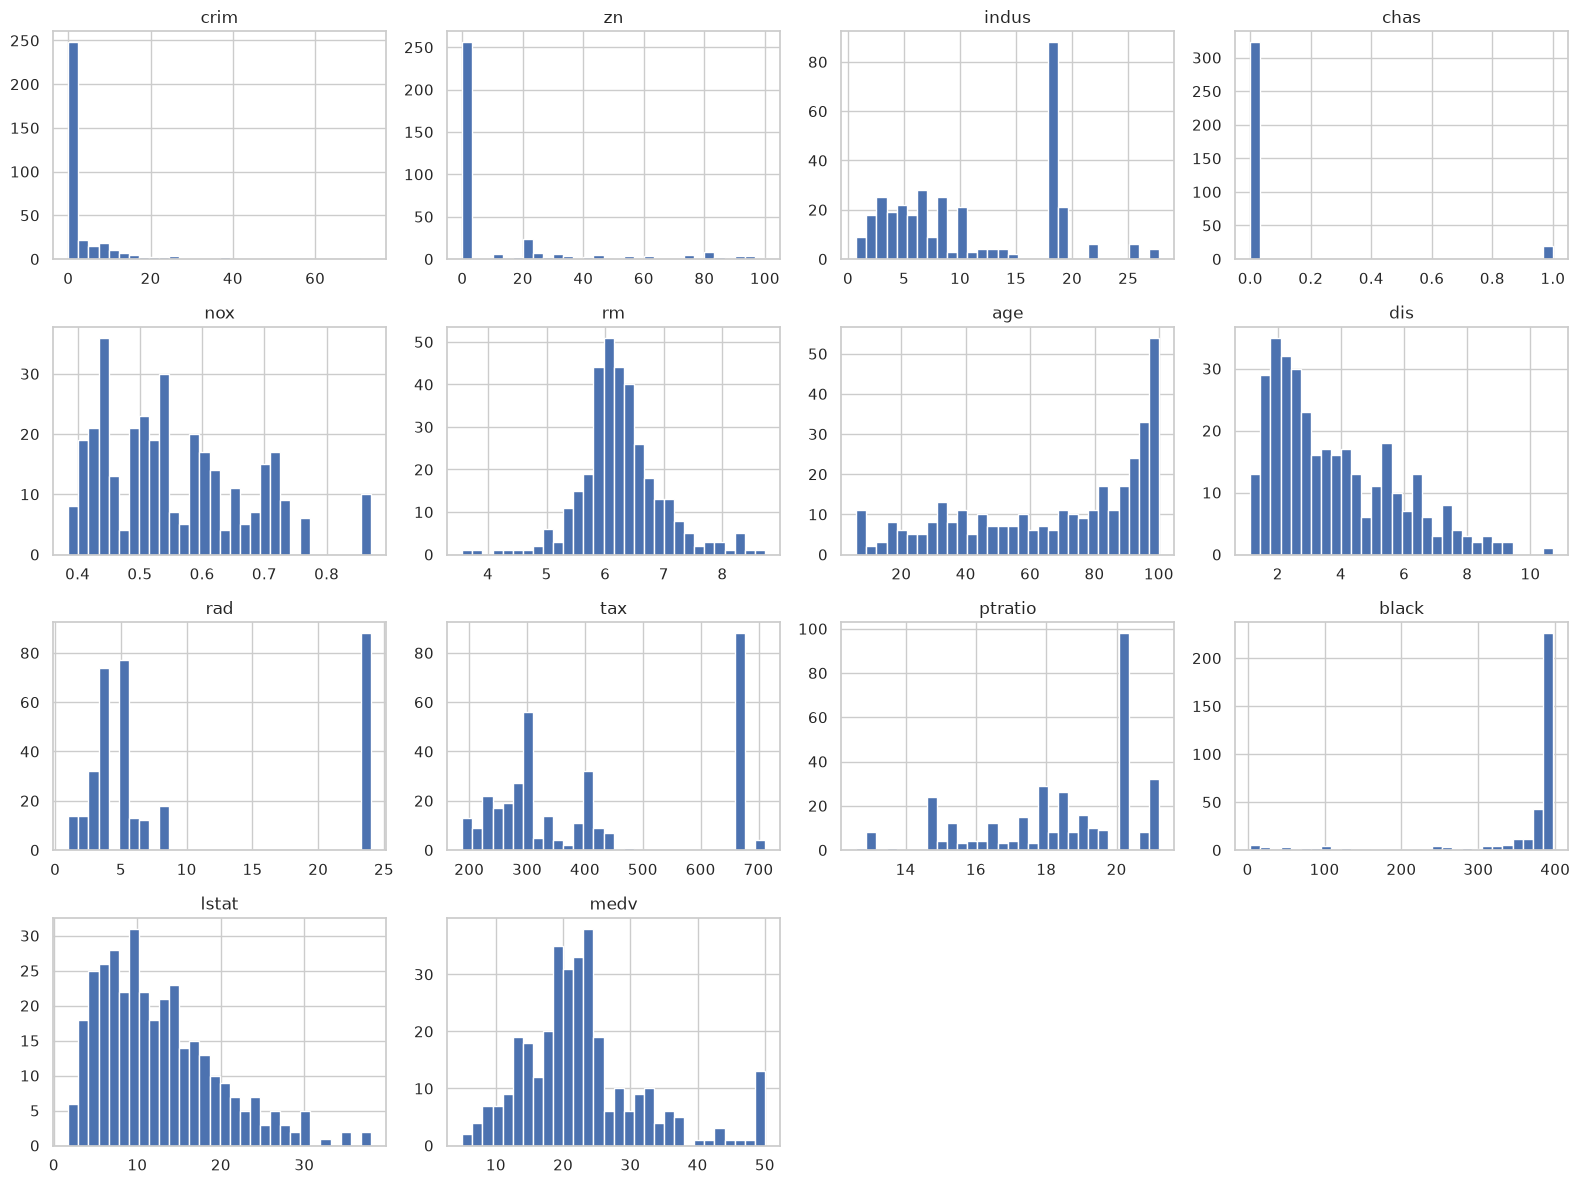

In [21]:
boston_df.hist(
    figsize=(16, 12),
    bins=30,
)

plt.tight_layout()
plt.show()

### Interpretación de los histogramas

Los histogramas muestran diferencias importantes en la forma de las distribuciones. Variables como `crim` y `zn` presentan una marcada concentración de observaciones en valores bajos y una cola hacia valores superiores, consistente con sus niveles elevados de asimetría. Otras variables presentan distribuciones más concentradas o relativamente simétricas.

En el caso de `chas` y `rad`, la interpretación debe realizarse como distribución de frecuencias de categorías o valores discretos, y no como si fueran variables continuas.

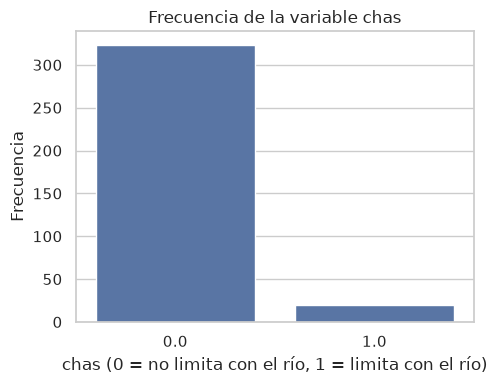

In [28]:
plt.figure(figsize=(5, 4))

sns.countplot(data=boston_df, x="chas")

plt.title("Frecuencia de la variable chas")
plt.xlabel("chas (0 = no limita con el río, 1 = limita con el río)")
plt.ylabel("Frecuencia")

plt.tight_layout()
plt.show()

### Interpretación de la frecuencia de `chas`

La variable `chas` presenta dos categorías, correspondientes a la ausencia o presencia de límite con el río Charles. La frecuencia observada muestra un claro predominio de la categoría 0 frente a la categoría 1. Debido a su naturaleza binaria, esta variable debe analizarse mediante frecuencias y proporciones, en lugar de utilizar interpretaciones propias de variables continuas.

# Boxplots

## Boxplots de todas las variables

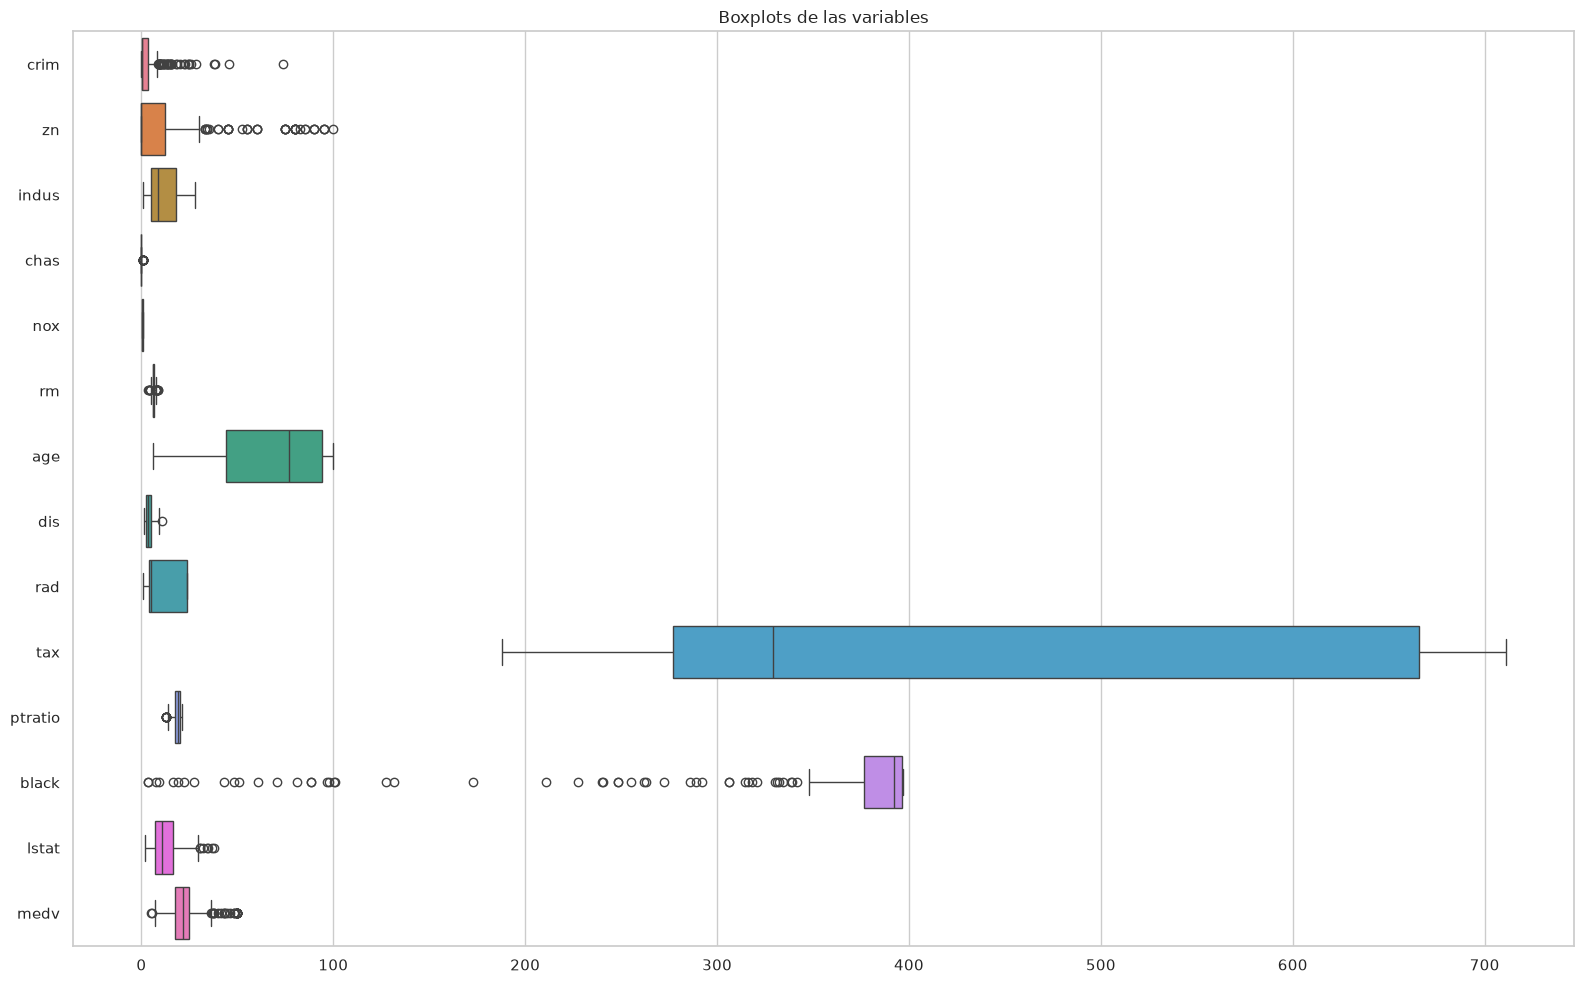

In [22]:
plt.figure(figsize=(16, 10))

sns.boxplot(
    data=boston_df,
    orient="h"
)

plt.title("Boxplots de las variables")
plt.tight_layout()
plt.show()

### Interpretación de los boxplots

El boxplot permite identificar diferencias en la dispersión y posibles valores extremos entre las variables. Sin embargo, al representar todas las variables conjuntamente, sus diferentes escalas dificultan la comparación visual, especialmente para variables con rangos pequeños. Por ello, los posibles valores atípicos deben analizarse de manera individual y complementarse con las estadísticas descriptivas y el criterio de IQR.

# Análisis de outliers

## Identificación mediante IQR

In [23]:
outlier_summary = []

for column in boston_df.columns:
    q1 = boston_df[column].quantile(0.25)
    q3 = boston_df[column].quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outliers = boston_df[
        (boston_df[column] < lower_bound)
        | (boston_df[column] > upper_bound)
    ][column].count()

    outlier_summary.append({
        "variable": column,
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "lower_bound": lower_bound,
        "upper_bound": upper_bound,
        "outliers": outliers,
        "outlier_%": outliers / len(boston_df) * 100,
    })

outlier_summary = pd.DataFrame(outlier_summary)

outlier_summary.round(2)

,variable,Q1,Q3,IQR,lower_bound,upper_bound,outliers,outlier_%
0,crim,0.08,3.44,3.36,-4.97,8.49,44,12.83
1,zn,0.00,12.50,12.50,-18.75,31.25,43,12.54
2,indus,5.13,18.10,12.97,-14.33,37.56,0,0.00
3,chas,0.00,0.00,0.00,0.00,0.00,20,5.83
4,nox,0.45,0.62,0.17,0.20,0.88,0,0.00
5,rm,5.89,6.59,0.71,4.83,7.65,21,6.12
6,age,44.03,93.88,49.85,-30.75,168.65,0,0.00
7,dis,2.14,5.21,3.07,-2.47,9.82,1,0.29
8,rad,4.00,24.00,20.00,-26.00,54.00,0,0.00
9,tax,277.00,666.00,389.00,-306.50,1249.50,0,0.00


### Interpretación de los valores atípicos mediante IQR

El criterio del rango intercuartílico (IQR) permite identificar observaciones que se encuentran fuera de los límites estadísticos definidos para las variables continuas. Entre las variables con mayor proporción de observaciones fuera de estos límites se encuentran `black` (14.29 %), `crim` (12.83 %) y `zn` (12.54 %), lo que es consistente con las distribuciones asimétricas observadas previamente.

Los resultados de `chas` y `rad` requieren una interpretación diferente. `chas` es una variable binaria, por lo que la aplicación del criterio IQR puede identificar como "atípicas" observaciones pertenecientes a una de sus categorías sin que esto implique que sean errores o valores anómalos. `rad`, por su parte, es una variable discreta con un número limitado de valores posibles, por lo que el criterio IQR tampoco resulta suficiente para determinar la existencia de valores atípicos. En consecuencia, estas variables no deben tratarse como continuas para la detección de outliers.

# Variable objetivo

## Identificación del target

In [24]:
TARGET = "medv"

print("Variable objetivo:", TARGET)
print("Tipo de dato:", boston_df[TARGET].dtype)
print("Valores nulos:", boston_df[TARGET].isnull().sum())

Variable objetivo: medv
Tipo de dato: float64
Valores nulos: 12


### Interpretación de la variable objetivo

`medv` corresponde a la variable objetivo del conjunto de datos. Presenta 12 valores nulos, equivalentes al 3.50 % de las observaciones, siendo la variable con mayor cantidad de datos faltantes. Debido a que estos valores corresponden a la variable que posteriormente se intentará predecir, su tratamiento deberá definirse durante la preparación de los datos antes del entrenamiento de los modelos.

# Distribución del target

## Histograma de medv

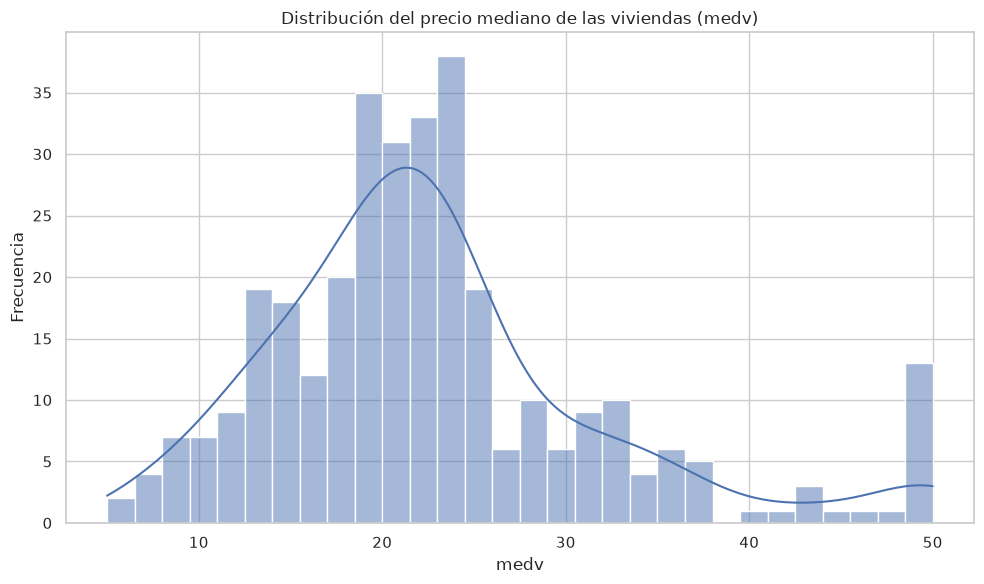

In [25]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=boston_df,
    x="medv",
    bins=30,
    kde=True,
)

plt.title("Distribución del precio mediano de las viviendas (medv)")
plt.xlabel("medv")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

## Boxplot del target

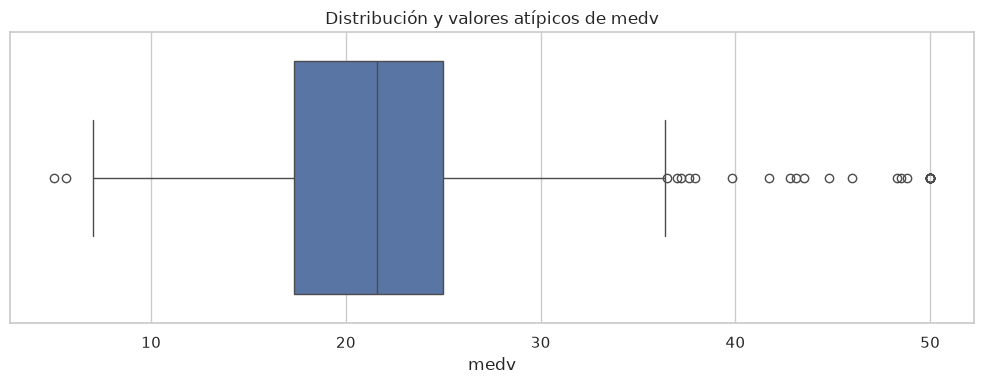

In [26]:
plt.figure(figsize=(10, 4))

sns.boxplot(
    data=boston_df,
    x="medv",
)

plt.title("Distribución y valores atípicos de medv")
plt.xlabel("medv")
plt.tight_layout()
plt.show()

In [29]:
print("Observaciones con medv = 50.00:", (boston_df["medv"] == 50.0).sum())

Observaciones con medv = 50.00: 11


### Interpretación de la distribución del target

`medv` presenta una distribución con asimetría moderada hacia la derecha (skewness = 1.13), con una media (22.73) superior a la mediana (21.60). El boxplot confirma la presencia de valores extremos en la cola superior.

Un dato relevante es que la moda de `medv` (50.00) coincide exactamente con su valor máximo. La verificación realizada muestra que **11 observaciones toman exactamente el valor 50.00**, lo que sugiere una posible censura o truncamiento del valor superior de la variable, un comportamiento conocido del dataset original de Boston Housing. Este patrón deberá considerarse en etapas posteriores de modelamiento, ya que puede afectar la representación de los valores más altos de la variable objetivo.


# Reglas preliminares de validación

## Posibles reglas de validación

### Reglas preliminares de validación

A partir del análisis univariable se pueden establecer reglas preliminares que posteriormente podrán implementarse mediante herramientas de validación de datos.

Estas reglas deberán verificarse y ajustarse antes de incorporarlas al pipeline definitivo.

In [27]:
validation_rules = {
    "crim": "Debe ser mayor o igual a 0",
    "zn": "Debe estar entre 0 y 100",
    "indus": "Debe ser mayor o igual a 0",
    "chas": "Debe tomar únicamente los valores 0 o 1",
    "nox": "Debe ser mayor que 0",
    "rm": "Debe ser mayor que 0",
    "age": "Debe estar entre 0 y 100",
    "dis": "Debe ser mayor que 0",
    "rad": "Debe ser un valor entero positivo dentro de las categorías observadas",
    "tax": "Debe ser mayor que 0",
    "ptratio": "Debe ser mayor que 0",
    "black": "Debe ser mayor o igual a 0",
    "lstat": "Debe ser mayor o igual a 0",
    "medv": "Debe ser mayor que 0",
}

validation_rules

{'crim': 'Debe ser mayor o igual a 0',
 'zn': 'Debe estar entre 0 y 100',
 'indus': 'Debe ser mayor o igual a 0',
 'chas': 'Debe tomar únicamente los valores 0 o 1',
 'nox': 'Debe ser mayor que 0',
 'rm': 'Debe ser mayor que 0',
 'age': 'Debe estar entre 0 y 100',
 'dis': 'Debe ser mayor que 0',
 'rad': 'Debe ser un valor entero positivo dentro de las categorías observadas',
 'tax': 'Debe ser mayor que 0',
 'ptratio': 'Debe ser mayor que 0',
 'black': 'Debe ser mayor o igual a 0',
 'lstat': 'Debe ser mayor o igual a 0',
 'medv': 'Debe ser mayor que 0'}

# Posibles transformaciones

## Identificación de transformaciones

### Posibles transformaciones

El análisis de las distribuciones permitirá identificar transformaciones que podrían ser necesarias antes de entrenar modelos de Machine Learning.

Entre las posibles transformaciones a evaluar posteriormente se encuentran:

- Tratamiento de valores nulos.
- Tratamiento de valores atípicos cuando sea necesario.
- Transformaciones para variables con alta asimetría.
- Escalamiento de variables numéricas para modelos sensibles a la escala.
- Codificación o tratamiento especial de variables discretas o binarias.
- Tratamiento de la variable objetivo cuando sea necesario.

Estas transformaciones no se aplicarán definitivamente en este notebook; se identificarán como posibles necesidades para las etapas posteriores del proyecto.

## 📊 Análisis de resultados y conclusiones

El análisis univariable permitió identificar las principales características y aspectos de calidad del conjunto de datos. El dataset contiene 343 observaciones y 14 variables, de las cuales `medv` corresponde a la variable objetivo. Aunque todas las variables están almacenadas como `float64`, `chas` presenta naturaleza binaria y `rad` naturaleza discreta/categórica, por lo que su interpretación debe considerar estas características.

Se identificaron valores nulos en 12 variables, con un máximo de 3.50 % en `medv`. También se encontraron 10 filas completamente duplicadas, las cuales deberán ser consideradas durante la etapa de preparación de los datos.

El análisis de las distribuciones mostró diferentes niveles de asimetría entre las variables. `crim`, `zn` y `black` presentan distribuciones particularmente asimétricas y una mayor presencia de valores extremos. La detección mediante IQR permitió identificar posibles valores atípicos en las variables continuas; sin embargo, este criterio no debe aplicarse de la misma manera a variables discretas o binarias como `chas` y `rad`.

La variable objetivo `medv` presenta una asimetría positiva moderada y valores extremos en la parte superior de su distribución. Se identificaron 11 observaciones con un valor exactamente igual a 50.00, coincidente con el máximo y la moda de la variable. Este comportamiento puede estar relacionado con la censura del valor superior presente en el dataset original y deberá considerarse durante las etapas posteriores del proyecto.

En conjunto, los resultados proporcionan un diagnóstico inicial de la estructura, calidad y distribución de las variables. Los hallazgos identificados servirán como base para las decisiones de limpieza, tratamiento de valores faltantes, manejo de duplicados, tratamiento de valores extremos y preparación de los datos para las siguientes etapas del proyecto.



## 💡Propuestas e ideas

A partir de los resultados del análisis univariable, se proponen las siguientes consideraciones para las etapas posteriores del proyecto:

Evaluar el tratamiento de los valores nulos, considerando de manera independiente los casos correspondientes a variables predictoras y a la variable objetivo medv.
Eliminar las filas completamente duplicadas identificadas durante la preparación de los datos.
Considerar la naturaleza binaria de chas y discreta/categórica de rad al definir las estrategias de transformación y modelamiento.
Evaluar el tratamiento de las variables con alta asimetría y de los valores extremos identificados en las variables continuas.
Revisar específicamente las 11 observaciones con medv = 50.00 debido a la posible censura del valor máximo de la variable objetivo.
Considerar el escalamiento de las variables numéricas en aquellos modelos que sean sensibles a la magnitud de las variables.
Complementar este diagnóstico con análisis bivariable y multivariable en las siguientes etapas, con el fin de estudiar las relaciones entre las variables predictoras y la variable objetivo.


## 📖 References



* Zapata, J. R. (2024). *Template Data Science Container*. https://joserzapata.github.io/

* Harrison, D., & Rubinfeld, D. L. (1978). *Hedonic housing prices and the demand for clean air*. Journal of Environmental Economics and Management, 5(1), 81–102. https://doi.org/10.1016/0095-0696(78)90006-2

* Pandas. (s. f.). *pandas.DataFrame.describe — pandas documentation*. https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.describe.html

* Seaborn. (s. f.). *seaborn documentation*. https://seaborn.pydata.org/
